In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Análise exploratória dos dados (EDA)

O diabetes é uma doença crônica grave na qual os indivíduos perdem a capacidade de regular efetivamente os níveis de glicose no sangue e pode levar a uma redução na qualidade de vida e na expectativa de vida.

O Sistema de Vigilância de Fatores de Risco Comportamentais (BRFSS) é uma pesquisa telefônica relacionada à saúde que é coletada anualmente pelo CDC (Centro de Controle e Prevenção de Doenças dos Estados Unidos). A cada ano, a pesquisa coleta respostas de milhares de americanos sobre comportamentos de risco relacionados à saúde, condições crônicas de saúde e o uso de serviços preventivos. Para este projeto, foi utilizado conjunto de dados disponível no Kaggle para o ano de 2015.

https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset

Dicionário de variáveis:

- `Diabetes_binary`: 0 = sem diabetes, 1 = com diabetes
- `HighBP`: 0 = sem pressão alta, 1 = com pressão alta
- `HighChol`: 0 = sem colesterol alto, 1 = com colesterol alto
- `CholCheck`: 0 = não fez exame de colesterol na vida, 1 = fez exame de colesterol alguma vez
- `BMI`: Índice de Massa Corporal (IMC)
- `Smoker`: 0 = não fumante, 1 = fumante
- `Stroke`: 0 = sem histórico de AVC, 1 = com histórico de AVC
- `HeartDiseaseorAttack`: 0 = sem histórico de doença cardíaca ou ataque cardíaco, 1 = com histórico de doença cardíaca ou ataque cardíaco
- `PhysActivity`: 0 = não pratica atividade física, 1 = pratica atividade física
- `Fruits`: 0 = não consome frutas, 1 = consome frutas
- `Veggies`: 0 = não consome vegetais, 1 = consome vegetais
- `HvyAlcoholConsump`: 0 = não consome álcool em altas quantidades, 1 = consome álcool em altas quantidades
- `AnyHealthcare`: 0 = não tem plano de saúde, 1 = tem plano de saúde
- `NoDocbcCost`: 0 = não foi ao médico por questões financeiras, 1 = foi ao médico por questões financeiras (últimos 12 meses)
- `GenHlth`: Saúde geral (1 a 5) - 1 = Excelente, 2 = Muito boa, 3 = Boa, 4 = Aceitável, 5 = Ruim
- `MentHlth`: Nos últimos 30 dias, quantos dias a saúde mental não foi boa (0 a 30)
- `PhysHlth`: Nos últimos 30 dias, quantos dias a saúde física não foi boa (0 a 30)
- `DiffWalk`: 0 = não tem dificuldade para caminhar, 1 = tem dificuldade para caminhar
- `Sex`: 0 = feminino, 1 = masculino
- `Age`: Idade em faixas 1 = 18-24; 2 = 25-29; 3 = 30-34; 4 = 35-39; 5 = 40-44; 6 = 45-49; 7 = 50-54; 8 = 55-59; 9 = 60-64; 10 = 65-69; 11 = 70-74; 12 = 75-79; 13 = 80+
- `Education`: Níveis de ensino 1 = nunca frequentou a escola; 2 = escola primária; 3 = escola secundária incompleta ; 4 = escola secundária; 5 = faculdade incompleta ou curso técnico; 6 = completou faculdade ou diplomas superiores
- `Income`: Renda anual (dólares) em faixas 1 = < 10.000; 2 = 10.000-14.999; 3 = 15.000-19.999; 4 = 20.000-24.999; 5 = 25.000-34.999; 6 = 35.000-49.999; 7 = 50.000-74.999; 8 = 75.000+

In [ ]:
import pandas as pd

BASE_DIABETES_TRATADA ="/content/drive/MyDrive/dados/diabetes_tratado.parquet"

df_diabetes_tratado = pd.read_parquet(BASE_DIABETES_TRATADA)

df_diabetes_tratado.head()

,Diabetes,PressaoAlta,ColesterolAlto,ColesterolExame,IMC,Fumante,AVC,ProblemaCardiaco,AtividadeFisica,ComeFrutas,...,PlanoDeSaude,SemDinheiroConsultas,SaudeGeral,DiasProblemasMentais,DiasProblemasFisicos,DificuldadeAndar,Genero,FaixaIdade,Ensino,FaixaRenda
0,Não,Sim,Não,Sim,26,Não,Não,Não,Sim,Não,...,Sim,Não,Boa,5,30,Não,Masculino,35-39,Faculdade +,75.000+
1,Não,Sim,Sim,Sim,26,Sim,Sim,Não,Não,Sim,...,Sim,Não,Boa,0,0,Não,Masculino,75-79,Faculdade +,75.000+
2,Não,Não,Não,Sim,26,Não,Não,Não,Sim,Sim,...,Sim,Não,Excelente,0,10,Não,Masculino,80+,Faculdade +,75.000+
3,Não,Sim,Sim,Sim,28,Sim,Não,Não,Sim,Sim,...,Sim,Não,Boa,0,3,Não,Masculino,70-74,Faculdade +,75.000+
4,Não,Não,Não,Sim,29,Sim,Não,Não,Sim,Sim,...,Sim,Não,Muito Boa,0,0,Não,Feminino,55-59,Faculdade inc ou Técnico,75.000+


In [ ]:
df_diabetes_tratado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Diabetes                70692 non-null  category
 1   PressaoAlta             70692 non-null  category
 2   ColesterolAlto          70692 non-null  category
 3   ColesterolExame         70692 non-null  category
 4   IMC                     70692 non-null  int8    
 5   Fumante                 70692 non-null  category
 6   AVC                     70692 non-null  category
 7   ProblemaCardiaco        70692 non-null  category
 8   AtividadeFisica         70692 non-null  category
 9   ComeFrutas              70692 non-null  category
 10  ComeVegetais            70692 non-null  category
 11  ConsumoBebidaAlcoolica  70692 non-null  category
 12  PlanoDeSaude            70692 non-null  category
 13  SemDinheiroConsultas    70692 non-null  category
 14  SaudeGeral            

In [ ]:
#Agora vamos colocar as colunas em variaveis para colunas especificas para facilitar em termos de codigo para fazer os graficos e afins

In [ ]:
colunas_numericas = df_diabetes_tratado.select_dtypes(include="number").columns.tolist()

coluna_alvo = "Diabetes"

colunas_categoricas = df_diabetes_tratado.select_dtypes(include="category").columns.tolist()
colunas_categoricas.remove(coluna_alvo)
#Estou removendo a coluna alvo porque eu quero que ela fique separada das outras porque
#Eu vou cruzar esses dados com outras variaveis.

colunas_binarias = df_diabetes_tratado.nunique()[df_diabetes_tratado.nunique() == 2].index.tolist()
colunas_binarias.remove(coluna_alvo)
#Estou filtrando as colunas que podem ter apenas dois valores

colunas_nao_binarias = list(set(colunas_categoricas) - set(colunas_binarias))
#Essa variavel estou fazendo o seguinte como eu ja crie as variaveis categoricas e as binarias
#Eu posso fazer fazer uma conta de menos para facilitar ou seja coluna categorica - binaria = não binaria
#E no python existe o comando set para ele pegar os valores dessa lista e list para ele voltar em formato de lista
#O set é um modelo de dados em python que lida muita bem com a junção ou remoção de elementos.
#Porem o set não guarda ordem como estava antes

In [ ]:
colunas_categoricas

['PressaoAlta',
 'ColesterolAlto',
 'ColesterolExame',
 'Fumante',
 'AVC',
 'ProblemaCardiaco',
 'AtividadeFisica',
 'ComeFrutas',
 'ComeVegetais',
 'ConsumoBebidaAlcoolica',
 'PlanoDeSaude',
 'SemDinheiroConsultas',
 'SaudeGeral',
 'DificuldadeAndar',
 'Genero',
 'FaixaIdade',
 'Ensino',
 'FaixaRenda']

In [ ]:
#Feito isso parece meio burocratico mais vai facilitar porque ao inves de ficar toda a hora escrevendo os nomes das colunas que eu quero
#Fica agora bem mais organizado e para futuras analizes tambem.

In [ ]:
## Variaveis numéricas

In [ ]:
#Agora vamos analisar a influencia dessas colunas numericas com a coluna alvo

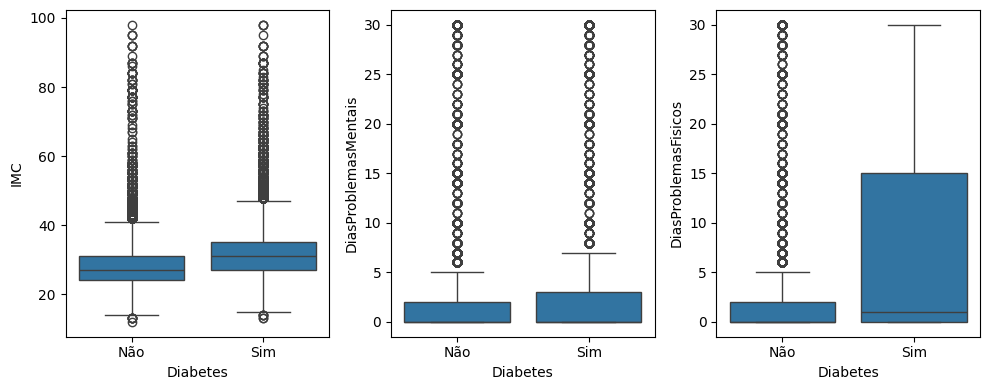

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fazendo uns sistemas de eixos
# E sabemos que temos 3 variaveis numericas
# Uma Figura com uma linha e tres colunas de graficos de sistemas de eixos.

fig, axs = plt.subplots(1, 3, figsize=(10, 4))

# Esse zip esta juntando os sistema de eixos e eu quero fazer uma associação de cada sistema eixo vai pra uma coluna numerica
# O zip vai fazer esse pareamento
for ax, coluna in zip(axs, colunas_numericas):
  sns.boxplot(data = df_diabetes_tratado, x = coluna_alvo, y = coluna, ax = ax)

plt.tight_layout() # Para dar um espaceamente e não ter essa sobreposição

plt.show()

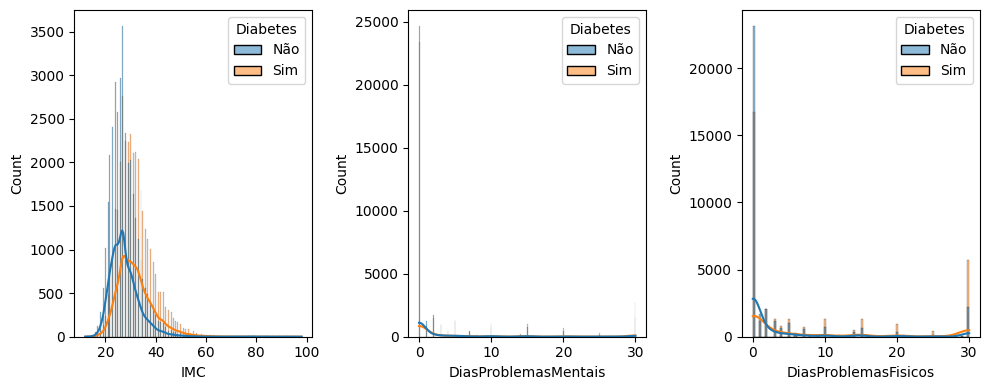

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 3, figsize=(10, 4))

for ax, coluna in zip(axs, colunas_numericas):
  sns.histplot(data = df_diabetes_tratado, x=coluna, hue=coluna_alvo, kde=True, ax=ax) # Eu estou usando o parametro hue pois eu quero os histogramas sejam diferenciados pela coluna alvo

plt.tight_layout()

plt.show()

In [ ]:
#Da para notas que np histograma como se trata de numeros inteiros fica esses fios pequenos e por se tratar de inteiro
#Não faz sentido fazer um teste de distruição normal, porque ele serve para variaveis continuas e os dias fica bem obvio
#Que naõ tem como fazer esse teste
#Porem no IMC eu vou conseguir fazer um teste estatistico.

*Atenção para os dados de IMC terem sido arredondados para inteiros.

*Será que considerar que há diferença entre diabé ticos e não diabéticos considerando IMC?

In [ ]:
#Estou fazendo um agrupamento para fazer um describe especifico.
df_diabetes_tratado.groupby(coluna_alvo, observed = False).describe().T # Esse T que coloquei vem de transposta, vem do conceito de matriz transposta
# Ele ta falando sobre esse orning que vai ser alterado e para tirar essa informação eu coloquei o parametro observed = FALSE
#Que seria, quando eu trabalho com colunas categorica e eu lidar com valores ausentes e se observed se eu quero ou não essse valores, porem nesse df não vem ao caso varia muito doque eu quero analisar.

Diabetes                             Não           Sim
IMC                  count  35346.000000  35346.000000
                     mean      27.769960     31.944011
                     std        6.187636      7.363401
                     min       12.000000     13.000000
                     25%       24.000000     27.000000
                     50%       27.000000     31.000000
                     75%       31.000000     35.000000
                     max       98.000000     98.000000
DiasProblemasMentais count  35346.000000  35346.000000
                     mean       3.042268      4.461806
                     std        7.208408      8.947717
                     min        0.000000      0.000000
                     25%        0.000000      0.000000
                     50%        0.000000      0.000000
                     75%        2.000000      3.000000
                     max       30.000000     30.000000
DiasProblemasFisicos count  35346.000000  35346.000000
                     mean       3.666355      7.954479
                     std        8.098339     11.301491
                     min        0.000000      0.000000
                     25%        0.000000      0.000000
                     50%        0.000000      1.000000
                     75%        2.000000     15.000000
                     max       30.000000     30.000000

In [ ]:
#Pelo describe a gente começa a ter as primeiras impressões dessa analise que tanto a media, desvio padrão, quartis e mim e max, estão sempre acima o sim doque o não, ou seja a gente percebe que tem diferença analisando a coluna IMC e as outras tambem tambemw tem.
#Podemos verificar se exite uma correlação entre elas

In [ ]:
df_diabetes_tratado.corr(numeric_only = True) # esse corr é para verificar se exite correlação entre as colunas e esse parametro numeric_only é que eu quero só as colunas que são numericas.

,IMC,DiasProblemasMentais,DiasProblemasFisicos
IMC,1.000000,0.104682,0.161862
DiasProblemasMentais,0.104682,1.000000,0.380272
DiasProblemasFisicos,0.161862,0.380272,1.000000


In [ ]:
#Exite correlação porem é uma correlação fraca, mas vamos começar com o IMC

In [ ]:
#Vamos começar a fazer alguns teste estatisticos.

In [ ]:
#Teste T de Student para comparar médias de IMC entre diabeticos e não diabeticos? (Teste Parametrico)
#Ou Test de Mann-Whitney U para comparar mediana de IMC entre diabeticos e não diabeticos?(Teste não Parametrico)

In [ ]:
#Primeiro precisamos ver se segue uma distribuição normal e se tem uma homogeniade de variancias.
#Mas sera que faz sentido fazer isso?

Faz sentido testar a normalidade das variáveis numéricas?

A verdadeira normalidade estatística é frequentemente considerada um mito no mundo real. Ao invés de buscar uma distribuição perfeitamente normal, o objetivo é avaliar se os dados são compatíveis com uma população normal para a aplicação de testes paramétricos.

Aqui está o detalhamento gradual do porquê isso acontece e como você deve lidar com essa suposição, baseado nos artigos fornecidos.

---

### 1. O Paradoxo do Tamanho da Amostra (O "Problema" dos Testes)

Os testes estatísticos de normalidade comparam a sua amostra com uma distribuição normal teórica. A hipótese nula desses testes é que "a distribuição da amostra é normal". No entanto, esses testes sofrem de um paradoxo dependente do tamanho da amostra (N):

*
**Em amostras pequenas:** Testes de normalidade têm muito pouco poder estatístico para rejeitar a hipótese nula. Isso significa que pequenas amostras quase sempre "passam" no teste de normalidade, não porque sejam de fato normais, mas porque o teste não tem dados suficientes para provar o contrário.


* **Em amostras grandes:** É aqui que o problema real de trabalhar com grandes *datasets* aparece. Com amostras grandes, qualquer desvio minúsculo da normalidade (que é inevitável em dados reais) fará com que o teste acuse um resultado significativo (valor-p < 0.05), rejeitando a normalidade. Esse pequeno desvio matemático, na prática, não afeta em nada os resultados de um modelo preditivo ou teste paramétrico.



### 2. A "Mágica" do Teorema do Limite Central (TLC)

A principal razão pela qual nos preocupamos com a normalidade é para garantir a validade de testes paramétricos (como regressão, correlação, testes T e ANOVA). Porém, o Teorema do Limite Central nos oferece uma excelente rede de segurança.

O teorema afirma que as médias de amostras aleatórias de *qualquer* distribuição terão, elas próprias, uma distribuição normal. Consequentemente:

* Se os dados da amostra forem aproximadamente normais, a distribuição amostral também será normal.


* Em grandes amostras (geralmente N > 30 ou 40), a distribuição amostral tende a ser normal, independentemente do formato original dos seus dados.


* Portanto, se você tiver amostras consistindo de centenas de observações, você pode frequentemente ignorar a distribuição original dos dados.



### 3. A Solução: Análise Visual > Valor-P

Dado que o teste de Kolmogorov-Smirnov (K-S) tem baixo poder e sequer é recomendado hoje em dia, e o teste de Shapiro-Wilk sofre do paradoxo do tamanho da amostra mencionado acima, a literatura moderna recomenda fortemente a **inspeção visual**.

Embora alguns considerem a avaliação visual subjetiva, ela permite que você entenda o comportamento real das suas variáveis. As melhores ferramentas para isso são:

*
**Histogramas e Boxplots:** Permitem um julgamento visual sobre o formato de sino da distribuição e ajudam a identificar facilmente a presença de *outliers* (valores atípicos).


*
**Gráficos P-P e Q-Q (Quantil-Quantil):** São considerados muito superiores e mais fáceis de interpretar em grandes amostras. No gráfico P-P, os dados são ranqueados e convertidos para um escore-z usando a fórmula teórica da distribuição normal:



$$z = \frac{x - \bar{x}}{\sigma}$$





Os escores reais são plotados contra os escores esperados. Se os dados forem perfeitamente distribuídos, o resultado será uma linha reta diagonal. Na prática, se os pontos seguirem essa linha sem desvios severos, a suposição de normalidade está mais do que satisfeita para os seus algoritmos.



---

**Resumo da Ópera:** Se você estiver trabalhando com projetos de inteligência computacional ou análises estatísticas em *datasets* grandes, rodar um teste de normalidade vai quase sempre retornar que seus dados "não são normais". Isso gera um alarme falso. Avalie a distribuição visualmente (através de gráficos Q-Q ou P-P) e confie no Teorema do Limite Central para manter a robustez das suas análises.


Imagine que você está processando os dados coletados pelas suas estações de monitoramento ambiental (usando sensores em ESP8266 integrados à plataforma Dojot, por exemplo) e seu objetivo é prever casos de dengue.

Você quer responder a uma pergunta estatística: **"A temperatura média nas áreas com focos de dengue é significativamente maior do que nas áreas sem focos?"**

Aqui está o passo a passo de como você aplica o Teorema do Limite Central e escolhe o teste na prática, direto no Python:

### Passo 1: O Tamanho da Amostra (O seu "N")

Você exporta os dados dos sensores via Python (usando o Pandas, por exemplo) e separa em dois grupos:

* **Área com focos:** 500 leituras de temperatura.
* **Área sem focos:** 450 leituras de temperatura.

### Passo 2: A Checagem Visual (O que a literatura recomenda)

Você não vai rodar um teste de Kolmogorov-Smirnov (K-S) aqui, porque com 500 linhas ele vai acusar erro por qualquer variação boba. Em vez disso, você plota um histograma e um gráfico Q-Q.

Ao olhar o gráfico, você percebe que a distribuição da temperatura está "torta" (assimétrica). Houve uma onda de calor na cidade e os dados estão concentrados nos valores mais altos. A distribuição original **não é normal**.

### Passo 3: O Veredito (A magia do TLC em ação)

É aqui que você toma a decisão analítica:

* **O que o amador faria:** "Meus dados de temperatura não são normais! O gráfico está torto! Tenho que usar um teste não paramétrico!"
* **O que você vai fazer:** Você olha para o seu tamanho de amostra (N = 500 e N = 450). Como o seu N é muito maior que 30 ou 40, o **Teorema do Limite Central entra em ação**. Ele garante que, mesmo a temperatura bruta sendo assimétrica, a *distribuição das médias* dessas temperaturas é perfeitamente normal.



**A Ação:** Você escolhe o **Teste T para amostras independentes (Paramétrico)** no Python (`scipy.stats.ttest_ind`). O resultado será estatisticamente robusto e confiável, e você terá muito mais poder para detectar uma diferença real entre as áreas do que se tivesse usado um teste não paramétrico.

---

### E quando o cenário muda? (O lado Não Paramétrico)

Agora, imagine um problema diferente no mesmo projeto. Em vez de sensores que coletam dados o dia todo, você está analisando **a quantidade de larvas do mosquito encontradas por armadilha**.

* **O Cenário:** Você tem dados de apenas 20 armadilhas (N = 20).
* **A Distribuição:** A maioria das armadilhas tem 0, 1 ou 2 larvas. Mas uma armadilha específica, instalada perto de um terreno baldio, tem 150 larvas.
* **O Problema:** A sua amostra é pequena (N < 30) e você tem um *outlier* gigantesco. A média de larvas será puxada lá para cima por causa dessa única armadilha problemática. A média não representa a realidade da maioria das armadilhas.
* **A Ação:** Como o N é pequeno, o TLC não consegue salvar a normalidade. Além disso, a mediana faz muito mais sentido analítico aqui do que a média. Portanto, você abandona os testes paramétricos e usa o **Teste U de Mann-Whitney (Não Paramétrico)**, que analisa o *ranqueamento* dos dados e não se deixa enganar por aquele valor de 150 larvas.

Na prática, a decisão se resume a dominar o seu conjunto de dados: olhar o tamanho do N, checar o formato visualmente para entender com o que está lidando e saber se a "Média" é a métrica que realmente responde à sua pergunta de pesquisa.

Usar o Teorema do Limite Central (TLC) na prática não significa rodar uma biblioteca específica no Python ou aplicar uma fórmula matemática complexa nos seus dados. Na verdade, você "usa" o TLC como um **guia de decisão** para escolher seus testes e como um **escudo argumentativo** para validar suas análises metodológicas.

Aqui está o passo a passo exato de como aplicar isso no fluxo de trabalho de um projeto de dados (como ao processar as leituras de temperatura da plataforma Dojot ou analisar métricas de faturamento do seu ERP):

### Passo 1: Defina e Valide o Tamanho da Amostra (O seu "N")

A primeira coisa a fazer é contar quantas linhas de dados válidas você tem para analisar.

*
**A Regra:** A literatura estatística afirma que, em amostras grandes (geralmente $N > 30$ ou $40$), a distribuição amostral tende a ser normal, independentemente do formato original dos dados.


* **A Aplicação:** Se você tem mais de 40 coletas (idealmente centenas), você acabou de "ativar" o TLC a seu favor. Com amostras consistindo de centenas de observações, muitas vezes podemos ignorar a distribuição original dos dados.



### Passo 2: Faça a Checagem Visual (Esqueça o Valor-P aqui)

Antes de rodar qualquer teste preditivo, você precisa conhecer o comportamento visual da sua variável.

*
**A Regra:** Testes rígidos de normalidade (como o Kolmogorov-Smirnov) têm baixo poder estatístico e não são recomendados como métrica definitiva. A verdadeira normalidade é considerada um mito, mas podemos procurar por ela visualmente usando gráficos.


*
**A Aplicação:** Plote um **Histograma** ou um **Gráfico P-P / Q-Q** no Python. Se os dados formarem um sino razoável (ou se alinharem na diagonal do gráfico P-P), ótimo. Se a distribuição for totalmente assimétrica ou cheia de buracos, você não precisa entrar em pânico — você já validou no Passo 1 que o seu $N$ é grande o suficiente para contornar isso.



### Passo 3: Escolha o Teste Focado na "Média"

O TLC não conserta dados quebrados, ele estabiliza as médias.

*
**A Regra:** O teorema central garante que as médias de amostras aleatórias de qualquer distribuição terão, elas próprias, uma distribuição normal.


*
**A Aplicação:** Como a sua distribuição de médias é normal, você tem o sinal verde para utilizar procedimentos paramétricos mesmo quando os dados em si não são normalmente distribuídos. Escolha testes como:


* **Teste T de Student:** Para comparar a média de dois grupos.
* **ANOVA:** Para comparar a média de três ou mais grupos.
* **Regressão Linear (ou XGBoost, dependendo do objetivo):** Para prever valores contínuos baseados nas suas *features*.



### Passo 4: Documente a Justificativa (A "Aplicação" Final)

É aqui que o TLC brilha no mundo real acadêmico e corporativo. Se você for questionado sobre o motivo de ter usado um teste paramétrico em dados "tortos", a sua justificativa será baseada no teorema.

* **Como escrever:** Em um relatório técnico, TCC ou artigo científico, você redige algo na linha de: *"Embora a inspeção visual através de histogramas tenha indicado assimetria na distribuição original dos dados, optou-se pela utilização de testes paramétricos. Essa decisão é fundamentada no Teorema do Limite Central, dado o elevado tamanho da amostra (N = 500), o que garante a normalidade da distribuição amostral das médias."*

Esse é o ciclo de vida prático do TLC. Ele te dá segurança para avançar com a estatística clássica e robusta sem ficar refém de dados perfeitamente simétricos.

Faz sentido testar a normalidade das variáveis numéricas?

In [ ]:
df_diabetes_tratado.groupby(coluna_alvo, observed = False).skew(numeric_only = True)

,IMC,DiasProblemasMentais,DiasProblemasFisicos
Diabetes,,,
Não,2.231015,2.808070,2.480202
Sim,1.527018,2.065169,1.150047


In [ ]:
#Aqui fiz um agrupamento para verificar a assimetria das 3 colunas numericas com relação a coluna alvo e esse .skew é para verificar a assimetria e (numeric_only = True), é para fazer somente com as variaveis numericas porque esse metodo não faz copm dados do tipo categoricos.

In [ ]:
#Você percebe que os valores, tanto no sim e quanto no não, tem valores positivos e analisando o histograma que fizemos faz o setindo de acordo com os valores.

In [ ]:
df_diabetes_tratado.groupby(coluna_alvo, observed = False)[colunas_numericas].apply(pd.DataFrame.kurtosis)
#Diferente da analise acima quando analisamos a curtose precisou fazer um codigo maior porque no pandas a uma falha não é só simplesmente usan o metodo igual acima;
#precisamos usar a função apply e indicar o que você quer porque a uma falaha no pandas que vc não pode usar a a função kutose no grouby
#[colunas_numericas] precisamos fazer isso para indicar que queremos somente as colunas numericas.

,IMC,DiasProblemasMentais,DiasProblemasFisicos
Diabetes,,,
Não,12.901012,7.012218,4.910598
Sim,5.717382,2.873176,-0.341922


In [ ]:
#Você percebe que os valores são bem altos no IMC e isso analisando o histograma faz total sentindo e lembrando do comportamento do grafico ele tem uma tendicia a ser leptocurtica.

In [ ]:
#Agora vamos realizar os testes de normalidade.
#Como é uma amostra grande inves de usar o teste de shapiro vamos ter que fazer o teste KS.

In [ ]:
dados_imc_sim = df_diabetes_tratado.query("Diabetes == 'Sim'")["IMC"].values
dados_imc_nao = df_diabetes_tratado.query("Diabetes == 'Não'")["IMC"].values

#Vou realizar o teste separadamente e vou filtrar apenas a coluna IMC e separando ela de sim e não e para fazer essa filtragem eu vou usar o query.

In [ ]:
from scipy.stats import kstest, norm

print(kstest(dados_imc_nao, norm.cdf, args=(dados_imc_nao.mean(), dados_imc_nao.std())))
print(kstest(dados_imc_sim, norm.cdf, args=(dados_imc_sim.mean(), dados_imc_sim.std())))
#O teste KS ele pede para passar alguns parametros como a media e o desvio padão para pegar o Zscore

KstestResult(statistic=np.float64(0.1209153634702329), pvalue=np.float64(0.0), statistic_location=np.int8(28), statistic_sign=np.int8(1))
KstestResult(statistic=np.float64(0.10452803408478695), pvalue=np.float64(0.0), statistic_location=np.int8(33), statistic_sign=np.int8(1))


In [ ]:
# Como pode ser observado o valor de p esta sendo menor que 0.05 e esta rejeitando a hipotese nula
#Porem quando falamos anteriormente não pode que o valor de p é menor que 0,05 e rejiotando a hipotese nula seja confiavel

In [ ]:
#Agora vamos verificar a homogeniadade de variancias usando o teste de levene

In [ ]:
#nessa função que criamos o parametro que colocamos que ela recebe um dataframe então vamos transformar em um dataframe e a agente coloca em dicionario.

dataframe_imc = pd.DataFrame({"Sim": dados_imc_sim, "Não": dados_imc_nao})

dataframe_imc

,Sim,Não
0,30,26
1,25,26
2,28,26
3,23,28
4,27,29
...,...,...
35341,37,23
35342,29,29
35343,25,24
35344,18,53


In [ ]:
from auxiliares import analise_levene

analise_levene(dataframe_imc, centro="median")#na analise levene passamos um parametro de centro e por padrão deixamos a media porem cololomos a media se é uma distribuição normal, como não é colocamos a mediana como centro

Teste de Levene
estatistica_levene=888.297
Ao menos uma variância é diferente (valor p: 0.000)


In [ ]:
#Analisando esse resultado de acordo com o teste e comparando as duas colunas não existe homogeniadade de variancias.

In [ ]:
#Porem esses teste de estão falhando, porque isso é normal eles falharem

In [ ]:
#Vamos analisar o resultados dos dois teste tanto o teste t para parametrico, quanto o teste de man whitney para não parametrico

In [ ]:
from auxiliares import analise_ttest_ind, analise_mannwhitneyu

analise_ttest_ind(dataframe_imc, variancias_iguais = False)#Coloquei variancias iguais = False porque ele não passou no teste de Levene porem mesmo não passando no teste de levene a gente pode usar o teste t, só precisa passar esse parametro

Teste t de Student
estatistica_ttest=81.591
Rejeita a hipótese nula (valor p: 0.000)


In [ ]:
#E analisando esse resultado, rejeita a impotese nula, ou seja que realmente tem difença entre o IMC entre as pessoas que tem ou não diabetes, considerando um nivel de significancia de 5%, que é valor padrão da função que criamos

In [ ]:
analise_mannwhitneyu(dataframe_imc)

Teste de Mann-Whitney
estatistica_mw=861173484.000
Rejeita a hipótese nula (valor p: 0.000)


In [ ]:
#Percebe que deu 0 cravado tambem.Então basicamente os dois teste dando o mesmo resultado independente se estou usando um parametrico ou não

In [ ]:
#E ai temos uma pergunta, será que o problema não seja os outliers?Porque temos muitos e o que aconteceria se tirarmos eles? Sera a gente teria o mesmo resultado?

##Os outliers inteferem?

In [ ]:
#Vamos fazer um estudo, porem retirando os outliers

In [ ]:
#existe varios jeitos e formas de como tratar os outliers,vamos fazer com base nesse contexto com o boxplot, mas vamos primeiro criar uma função:

In [ ]:
def remove_outliers(dados, largura_bigodes=1.5):
  q1 = dados.quantile(0.25)#O método quantile() do Pandas serve para calcular medidas de posição em um conjunto de dados, dividindo-os em partes proporcionais
  q3 = dados.quantile(0.75)
  iqr = q3 - q1 #formula do intervalo interquartil
  return dados[(dados >= q1 - largura_bigodes * iqr) & (dados <= q3 + largura_bigodes * iqr)]

In [ ]:
df_diabetes_sem_outliers = df_diabetes_tratado.copy()

for coluna in colunas_numericas: #Pois essa anaalise que estamos fazendo so funciona nas colunas numericas
  df_diabetes_sem_outliers[coluna] = remove_outliers(df_diabetes_sem_outliers[coluna])

df_diabetes_sem_outliers.describe()

,IMC,DiasProblemasMentais,DiasProblemasFisicos
count,68511.000000,58876.000000,60068.000000
mean,29.129673,0.526615,1.880619
std,5.695466,1.271375,3.727202
min,13.000000,0.000000,0.000000
25%,25.000000,0.000000,0.000000
50%,28.000000,0.000000,0.000000
75%,33.000000,0.000000,2.000000
max,45.000000,5.000000,15.000000


In [ ]:
df_diabetes_sem_outliers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Diabetes                70692 non-null  category
 1   PressaoAlta             70692 non-null  category
 2   ColesterolAlto          70692 non-null  category
 3   ColesterolExame         70692 non-null  category
 4   IMC                     68511 non-null  float64 
 5   Fumante                 70692 non-null  category
 6   AVC                     70692 non-null  category
 7   ProblemaCardiaco        70692 non-null  category
 8   AtividadeFisica         70692 non-null  category
 9   ComeFrutas              70692 non-null  category
 10  ComeVegetais            70692 non-null  category
 11  ConsumoBebidaAlcoolica  70692 non-null  category
 12  PlanoDeSaude            70692 non-null  category
 13  SemDinheiroConsultas    70692 non-null  category
 14  SaudeGeral            

In [ ]:
#Agora vamos refazer os nossos estudos com esse novo dataframe e ver se realmente vai ter diferença

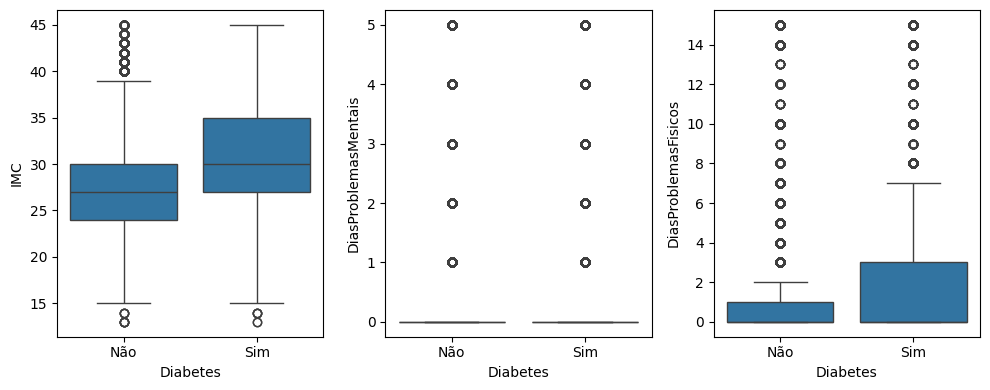

In [ ]:
fig,axs = plt.subplots(1, 3, figsize=(10, 4))

for ax, coluna in zip(axs, colunas_numericas):
  sns.boxplot(data = df_diabetes_sem_outliers, x =coluna_alvo, y = coluna, ax = ax)

plt.tight_layout()
plt.show()

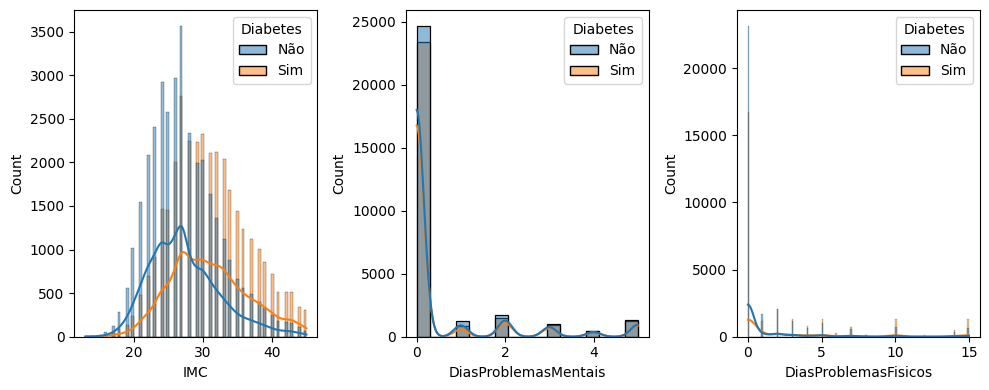

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(10, 4))

for ax, coluna in zip(axs, colunas_numericas):
  sns.histplot(data = df_diabetes_sem_outliers, x = coluna, hue = coluna_alvo, kde = True, ax=ax)

plt.tight_layout()
plt.show()

In [ ]:
#vamos analisar assimetria e curtose

In [ ]:
df_diabetes_sem_outliers.groupby(coluna_alvo, observed = False).skew(numeric_only = True)

,IMC,DiasProblemasMentais,DiasProblemasFisicos
Diabetes,,,
Não,0.714415,2.454599,2.874805
Sim,0.323244,2.507093,1.856026


In [ ]:
df_diabetes_sem_outliers.groupby(coluna_alvo, observed = False)[colunas_numericas].apply(pd.DataFrame.kurtosis)

,IMC,DiasProblemasMentais,DiasProblemasFisicos
Diabetes,,,
Não,0.481335,5.003764,8.079214
Sim,-0.343434,5.185706,2.367289


In [ ]:
#Analisando a simetria percebe que por mais que são valores positivos ainda, porem são valores menores, e estamos se aprocimando de uma simetria

In [ ]:
#E já curtose é o mesmo raciocinio os valores estão proximos de zero indicando que está proximo de uma distribuição normal, indicando um comportamento mesocurtica

In [ ]:
dados_imc_sim_sem_outliers = df_diabetes_sem_outliers.query("Diabetes == 'Sim'")["IMC"].values
dados_imc_nao_sem_outliers = df_diabetes_sem_outliers.query("Diabetes == 'Não'")["IMC"].values

dataframe_imc_sem_outliers = pd.DataFrame({"Sim": dados_imc_sim_sem_outliers, "Não": dados_imc_nao_sem_outliers})
dataframe_imc_sem_outliers

,Sim,Não
0,30.0,26.0
1,25.0,26.0
2,28.0,26.0
3,23.0,28.0
4,27.0,29.0
...,...,...
35341,37.0,23.0
35342,29.0,29.0
35343,25.0,24.0
35344,18.0,NaN


In [ ]:
#Vamos para os teste de normalidade

In [ ]:
print(kstest(dados_imc_nao_sem_outliers, norm.cdf, args=(dados_imc_nao_sem_outliers.mean(), dados_imc_nao_sem_outliers.std()), nan_policy = "omit"))
print(kstest(dados_imc_sim_sem_outliers, norm.cdf, args=(dados_imc_sim_sem_outliers.mean(), dados_imc_sim_sem_outliers.std()), nan_policy = "omit"))

KstestResult(statistic=np.float64(nan), pvalue=np.float64(nan), statistic_location=np.float64(13.0), statistic_sign=np.int8(-1))
KstestResult(statistic=np.float64(nan), pvalue=np.float64(nan), statistic_location=np.float64(13.0), statistic_sign=np.int8(-1))


In [ ]:
dados_imc_nao_sem_outliers.mean() #Deu NaN porque veio como array do numpy

np.float64(nan)

In [ ]:
dataframe_imc_sem_outliers["Não"].mean() #Agora se eu pego a coluna do dataframe e ele me traz o valor, porque por padrão quando eu uso a media do dataframe ele desconsidera os dados ausentes por padrão

np.float64(27.39410195358444)

In [ ]:
#Você percebe que os numeros nulos estão interferindo porque ele está puxando a media e desvio padrão do meu dataframe então ao inves de fazer pela variavel que criamos vamos fazer pelo dataframe direto e omitir os nulos por lá

In [ ]:
print(
    kstest(
        dataframe_imc_sem_outliers["Não"],
        norm.cdf,
        args=(dataframe_imc_sem_outliers["Não"].mean(),
              dataframe_imc_sem_outliers["Não"].std()),
        nan_policy="omit")
)

print(
    kstest(
        dataframe_imc_sem_outliers["Sim"],
        norm.cdf,
        args=(dataframe_imc_sem_outliers["Sim"].mean(),
              dataframe_imc_sem_outliers["Sim"].std()),
        nan_policy="omit")
)

KstestResult(statistic=np.float64(0.10815079726309146), pvalue=np.float64(0.0), statistic_location=np.float64(27.0), statistic_sign=np.int8(1))
KstestResult(statistic=np.float64(0.07345716240963396), pvalue=np.float64(2.3370072025339465e-158), statistic_location=np.float64(30.0), statistic_sign=np.int8(1))


In [ ]:
analise_levene(dataframe_imc_sem_outliers, centro="median")

Teste de Levene
estatistica_levene=532.986
Ao menos uma variância é diferente (valor p: 0.000)


In [ ]:
analise_ttest_ind(dataframe_imc_sem_outliers, variancias_iguais = False)

Teste t de Student
estatistica_ttest=85.248
Rejeita a hipótese nula (valor p: 0.000)


In [ ]:
analise_mannwhitneyu(dataframe_imc_sem_outliers)

Teste de Mann-Whitney
estatistica_mw=801702843.000
Rejeita a hipótese nula (valor p: 0.000)


In [ ]:
#Ou seja percebemos que tem sim difrença entre os valores e isso fica bem visivel ao analisar o boxplot e o histograma

Variáveis Categóricas

Esse é cojunto de histogramas de variaveis categoricas binarias.

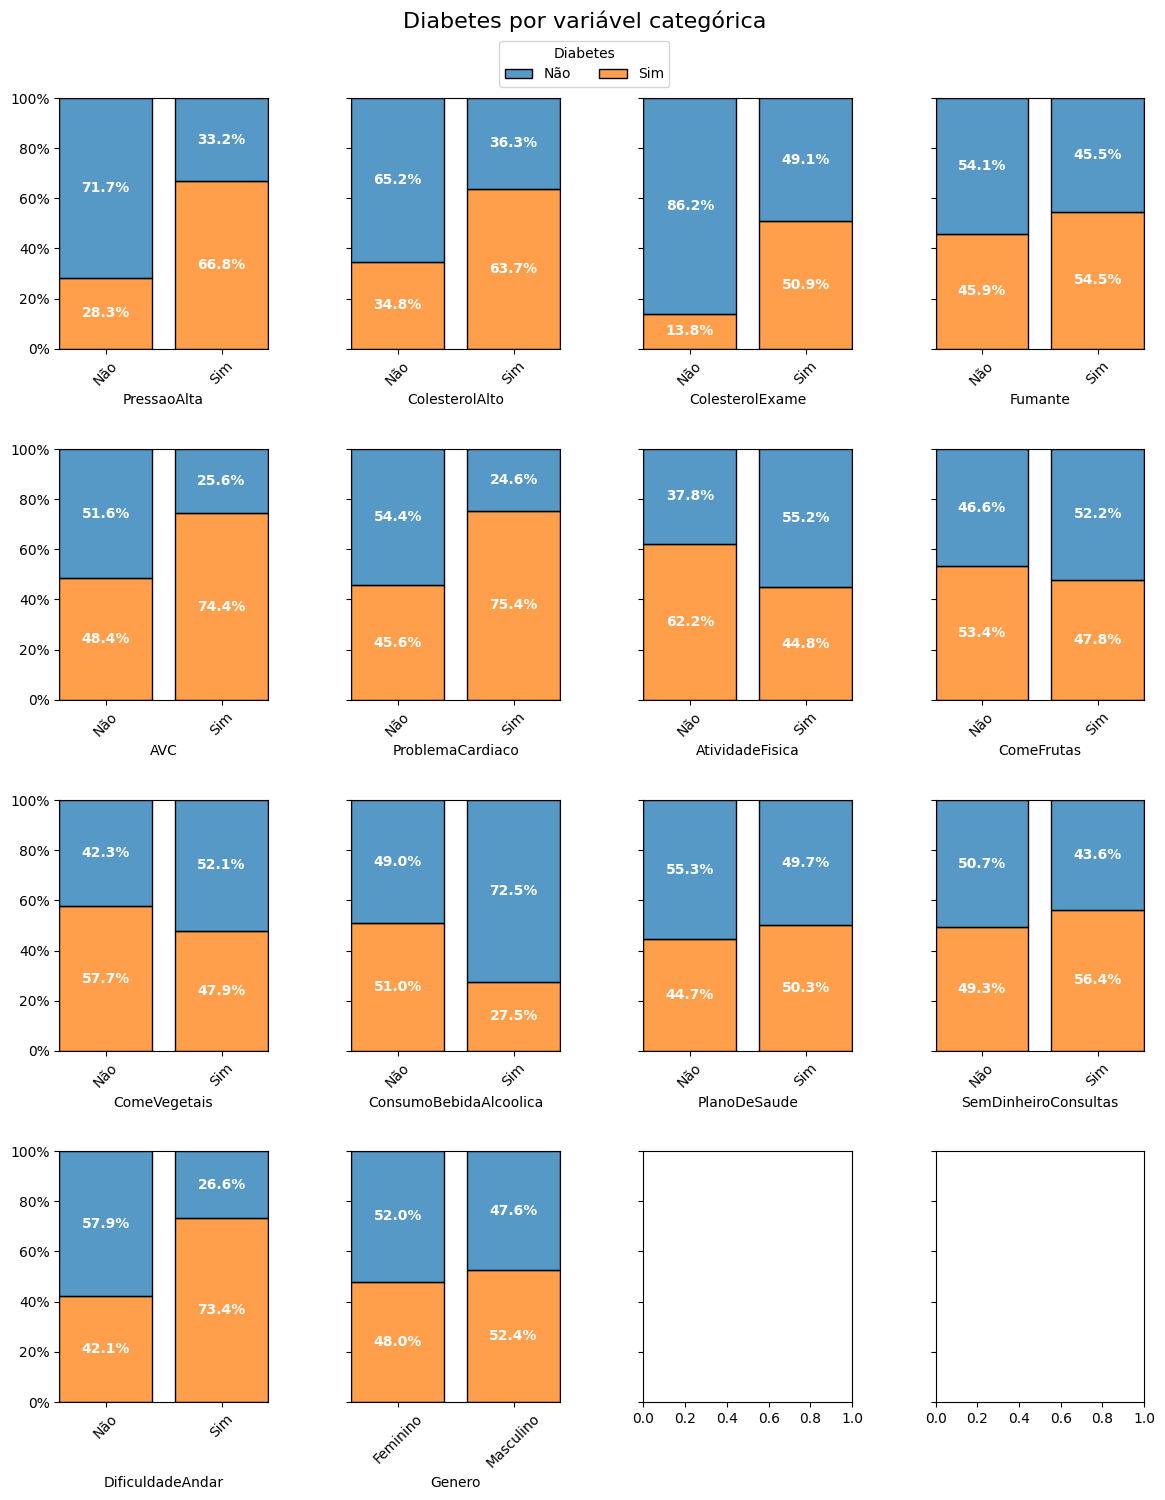

In [ ]:
from matplotlib.ticker import PercentFormatter

fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(14, 16), sharey=True)

for i, coluna in enumerate(colunas_binarias):
    h = sns.histplot(x=coluna,
                     hue=coluna_alvo,
                     data=df_diabetes_tratado,
                     multiple='fill',
                     ax=axs.flat[i],
                     stat='percent',
                     shrink=0.8)
    h.tick_params(axis='x', labelrotation=45)

    h.yaxis.set_major_formatter(PercentFormatter(1))
    h.set_ylabel('')

    for bar in h.containers:
        h.bar_label(bar, label_type='center', labels=[f'{b.get_height():.1%}' for b in bar], color='white', weight='bold')

    legend = h.get_legend()
    legend.remove()

labels = [text.get_text() for text in legend.get_texts()]

fig.legend(handles=legend.legend_handles, labels=labels, loc='upper center', ncols=2, title='Diabetes', bbox_to_anchor=(0.5, 0.965))
fig.suptitle('Diabetes por variável categórica', fontsize=16)

fig.align_labels()

plt.subplots_adjust(wspace=0.4, hspace=0.4, top=0.925)

plt.show()

In [ ]:
#E agora começos analisar o histograma como por exemplo o pressão alta é um grande fator você percebe que quem tem pressão alta tem diabetes;

Variaveis Categoricas Parte II

Agora é um conjunto de histogramas de variaveis categoricas não binarias.

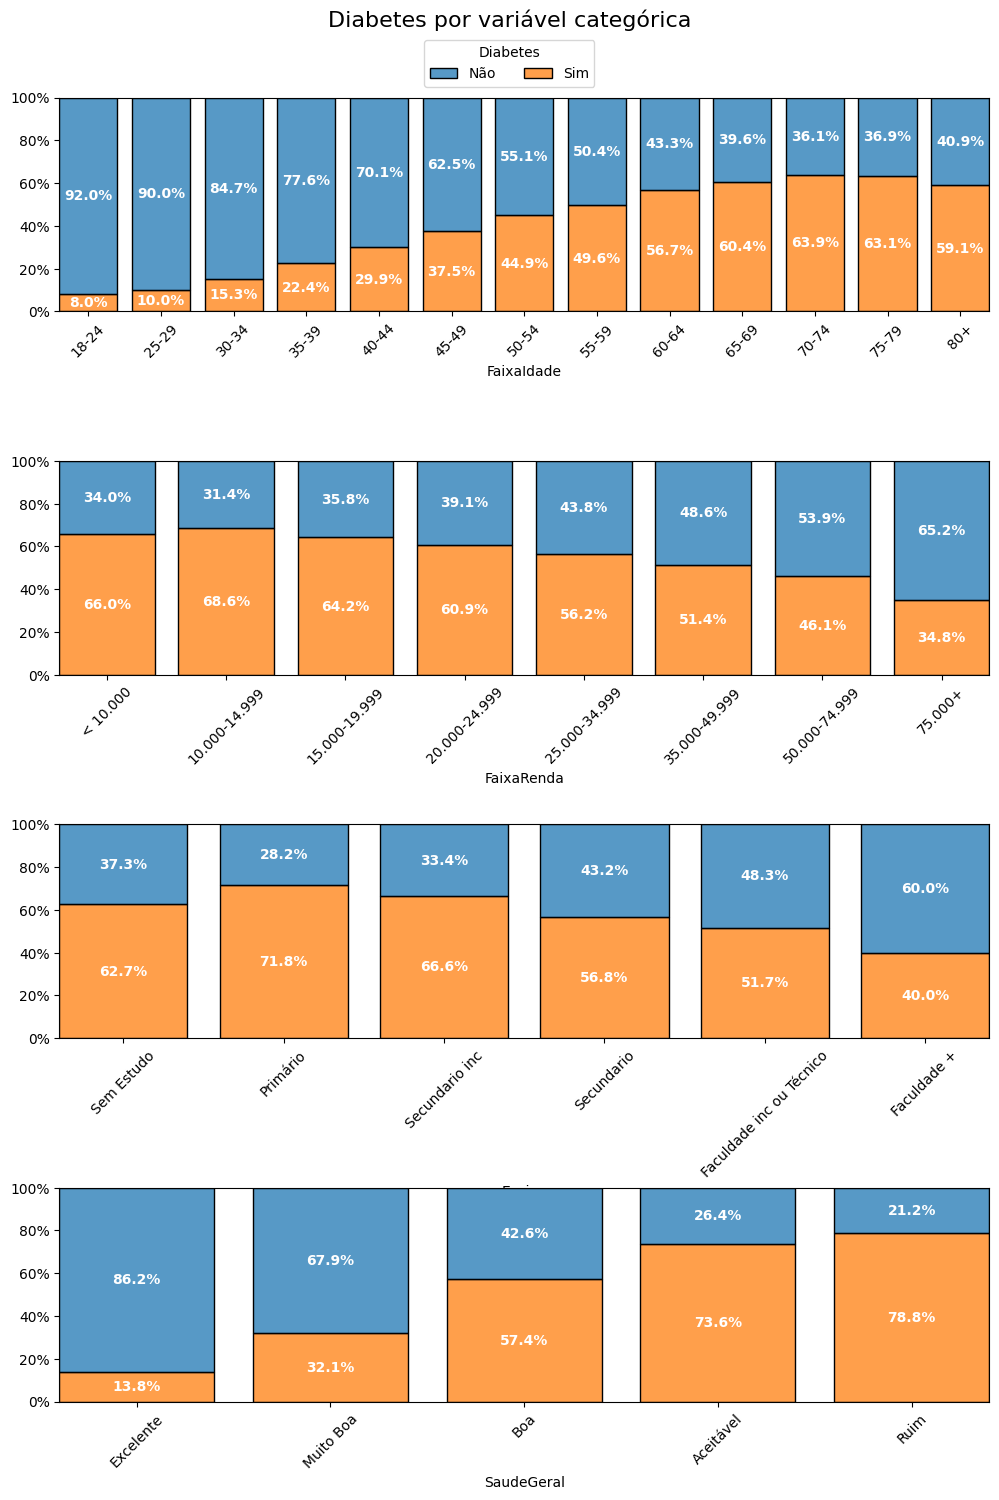

In [ ]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(12, 16))

for i, coluna in enumerate(colunas_nao_binarias):
    h = sns.histplot(x=coluna,
                     hue=coluna_alvo,
                     data=df_diabetes_tratado,
                     multiple='fill',
                     ax=axs.flat[i],
                     stat='percent',
                     shrink=0.8)
    h.tick_params(axis='x', labelrotation=45)

    h.yaxis.set_major_formatter(PercentFormatter(1))
    h.set_ylabel('')

    for bar in h.containers:
        h.bar_label(bar, label_type='center', labels=[f'{b.get_height():.1%}' for b in bar], color='white', weight='bold')

    legend = h.get_legend()
    legend.remove()

labels = [text.get_text() for text in legend.get_texts()]

fig.legend(handles=legend.legend_handles, labels=labels, loc='upper center', ncols=2, title='Diabetes', bbox_to_anchor=(0.5, 0.965))
fig.suptitle('Diabetes por variável categórica', fontsize=16)

fig.align_labels()

plt.subplots_adjust(wspace=0.1, hspace=0.7, top=0.925)

plt.show()

In [ ]:
#Você ja percebe de cara que quando vizualizamos os graficos o primeiro histograma de Saude você percebe que quem tem diabetes tem uma saude muito ruim; Na Faixa de idade observa que quem tem diabetes geralmente é um publico mais velho; E vocÊ percebe que na faixa de renda geralmente são pessoa que tem um menor poder aquisitivo que tem mais diabetes.

Variaveis Categoricas Parte III



In [ ]:
#Agora vamos parar de comparar com a nossa coluna alvo e fazer outras relações graficas.Nesse caso vai ser Saude Geral e Faixa de Renda

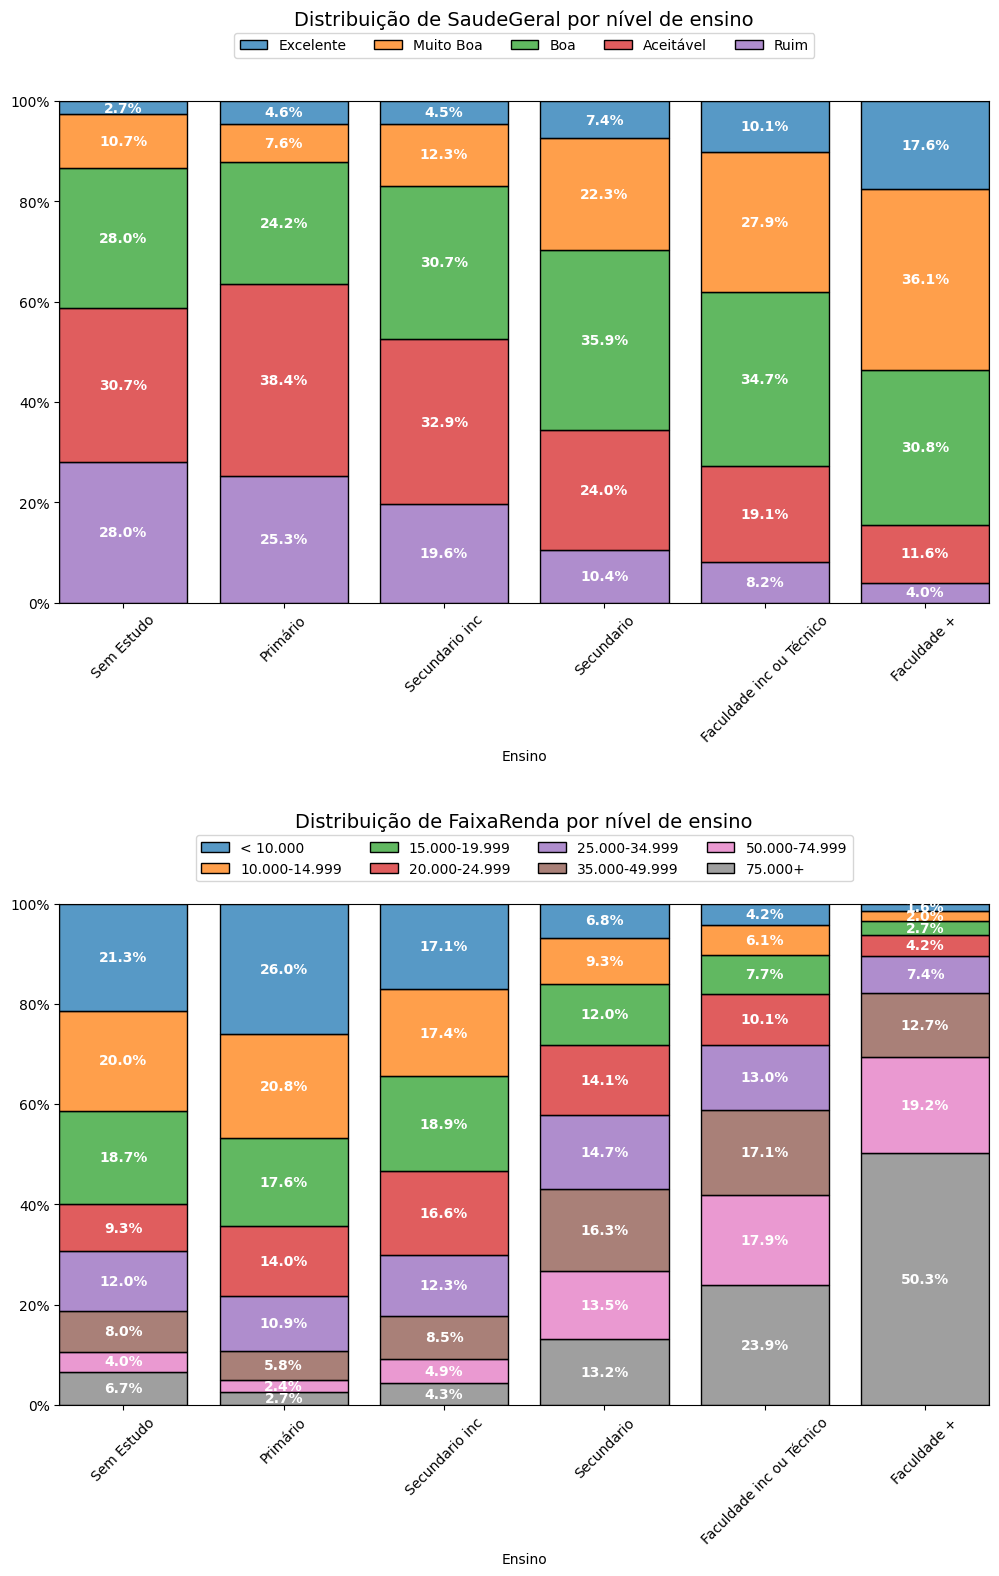

In [ ]:
colunas_analise = ["SaudeGeral", "FaixaRenda"]

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12, 16))

for ax, coluna in zip(axs.flatten(), colunas_analise):#A função .flatten() em axs transforma uma matriz multidimensional de eixos em um array unidimensional (uma única linha de elementos)
    h = sns.histplot(x="Ensino",
                     hue=coluna,
                     data=df_diabetes_tratado,
                     multiple='fill',
                     ax=ax,
                     stat='percent',
                     shrink=0.8)
    h.tick_params(axis='x', labelrotation=45)

    h.yaxis.set_major_formatter(PercentFormatter(1))
    h.set_ylabel('')

    for bar in h.containers:
        h.bar_label(bar, label_type='center', labels=[f'{b.get_height():.1%}' for b in bar], color='white', weight='bold')

    legend = h.get_legend()

    labels = [text.get_text() for text in legend.get_texts()]

    numero_itens = len(df_diabetes_tratado[coluna].cat.categories)#Esse codigo serve para acessar diretamente os nomes das categorias
    ax.legend(
        handles=legend.legend_handles,
        labels=labels,
        loc="upper center", #onde eu quero que fica posicionado a minha legenda
        ncols=numero_itens if numero_itens <= 6 else min(4, numero_itens), #Estou fazendo esse if porque quando tem varias categorias fica muito ruim para vizualizar então a apartir 6 ele precisa quebrar para conseguir ver vizualmente melhor
        bbox_to_anchor=(0.5, 1.15),#Tamanho da minha legenda
    )

    ax.set_title(f"Distribuição de {coluna} por nível de ensino", fontsize=14, pad=55) #Titulo do grafico e esse pad serve para dar uma distancia entre o titulo e meu sistema de eixos do grafico

plt.subplots_adjust(wspace=0.1, hspace=0.6, top=0.925)

plt.show()

In [ ]:
#Uma dica não é para ficar preso a coluna alvo, podemos analisar outros dados, logico que a coluna alvo é o nosso objetivo mas nada impede de analisar outros dados.

In [ ]:
#E vocÊ percebe que quanto maior o nivel de ensino maior o nivel de saude geral.E ao contrario conforme é menor o nivel de estudo menor é o nivel de saude e ai vocÊ percebe que esssas duas colunas categoricas tem correlação

In [ ]:
#Ja no outro grafico de faixa de renda você percebe que conforme a pessoa tem um nivel educacional maior, melhor é a sua faixa de renda.

Variaveis Categoricas Parte IV



In [ ]:
#Agora vamos criar tabelas de contingencia para cruzar os dados.E vamos adicionar elas num dicionario para analisar essas tabelas em outras situações

In [ ]:
tabelas_contingencia = {} #Agora vamos fazer o pareamento de cada uma dessas colunas com a nossa coluna alvo

for coluna in df_diabetes_tratado.select_dtypes("category").columns:
  if coluna != coluna_alvo: #è que não faz sentido usar a coluna alvo porque ela é uma variavel do tipo categorico então não faz sentido olhar para ela
    tabelas_contingencia[coluna] = pd.crosstab(df_diabetes_tratado[coluna_alvo], df_diabetes_tratado[coluna])# criar tabelas de contingência que mostram a frequência de ocorrência de combinações entre duas ou mais variáveis categóricas


In [ ]:
tabelas_contingencia["PressaoAlta"]

PressaoAlta,Não,Sim
Diabetes,,
Não,22118,13228
Sim,8742,26604


In [ ]:
for coluna in df_diabetes_tratado.select_dtypes("category").columns: #Vamos alterar a forma de vizualizar como tava sendo feito anteriormente usadno o display
    if coluna != coluna_alvo:
        display(
            pd.crosstab(
                df_diabetes_tratado[coluna_alvo],
                df_diabetes_tratado[coluna],
                margins=True,
                normalize="index"
            ).style.format("{:.2%}"))

PressaoAlta,Não,Sim
Diabetes,,
Não,62.58%,37.42%
Sim,24.73%,75.27%
All,43.65%,56.35%


ColesterolAlto,Não,Sim
Diabetes,,
Não,61.87%,38.13%
Sim,32.99%,67.01%
All,47.43%,52.57%


ColesterolExame,Não,Sim
Diabetes,,
Não,4.27%,95.73%
Sim,0.68%,99.32%
All,2.47%,97.53%


Fumante,Não,Sim
Diabetes,,
Não,56.77%,43.23%
Sim,48.18%,51.82%
All,52.47%,47.53%


AVC,Não,Sim
Diabetes,,
Não,96.81%,3.19%
Sim,90.75%,9.25%
All,93.78%,6.22%


...

DificuldadeAndar,Não,Sim
Diabetes,,
Não,86.58%,13.42%
Sim,62.88%,37.12%
All,74.73%,25.27%


Genero,Feminino,Masculino
Diabetes,,
Não,56.51%,43.49%
Sim,52.09%,47.91%
All,54.30%,45.70%


FaixaIdade,18-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60-64,65-69,70-74,75-79,80+
Diabetes,,,,,,,,,,,,,
Não,2.55%,3.55%,4.91%,6.13%,6.99%,8.22%,10.71%,12.28%,12.39%,12.16%,8.21%,5.63%,6.27%
Sim,0.22%,0.40%,0.89%,1.77%,2.97%,4.93%,8.74%,12.06%,16.22%,18.55%,14.54%,9.63%,9.08%
All,1.38%,1.97%,2.90%,3.95%,4.98%,6.58%,9.72%,12.17%,14.30%,15.36%,11.38%,7.63%,7.68%


Ensino,Sem Estudo,Primário,Secundario inc,Secundario,Faculdade inc ou Técnico,Faculdade +
Diabetes,,,,,,
Não,0.08%,1.31%,3.26%,23.78%,27.38%,44.19%
Sim,0.13%,3.35%,6.50%,31.31%,29.29%,29.42%
All,0.11%,2.33%,4.88%,27.55%,28.33%,36.81%


FaixaRenda,< 10.000,10.000-14.999,15.000-19.999,20.000-24.999,25.000-34.999,35.000-49.999,50.000-74.999,75.000+
Diabetes,,,,,,,,
Não,3.47%,3.99%,5.63%,7.37%,9.92%,14.13%,17.43%,38.06%
Sim,6.74%,8.73%,10.09%,11.47%,12.74%,14.97%,14.90%,20.36%
All,5.11%,6.36%,7.86%,9.42%,11.33%,14.55%,16.16%,29.21%


In [ ]:
#Resumidamente estou verificando a associação entres eles com a coluna alvo basicamente é uma outra forma de ver a diferença igual como fizemos anteriormente com os histogramas.

In [ ]:
#O código nas células anteriores cria tabelas de contingência que mostram a frequência de ocorrência de combinações entre as variáveis categóricas e a coluna alvo ('Diabetes'). Ao normalizá-las por índice e formatá-las como porcentagens, você está, de fato, verificando a associação entre essas variáveis e a presença de diabetes, o que é uma forma de visualizar as diferenças, muito semelhante à análise que você fez com os histogramas

In [ ]:
#Ou seja se a gente usasse um teste Qui quadrado usada para analisar dados categóricos, comparar frequências observadas com as esperadas e verificar se existe associação entre variáveis seria basicamente verificar se tem difença entre as associações como estamos fazendo acima.

In [ ]:
from scipy.stats import chi2_contingency

for coluna, tabela in tabelas_contingencia.items():
    chi2, valor_p, _, _ = chi2_contingency(tabela)# Aqui passei que eu so quero dois valores pois ele me retorna diversos outros valoes mas nesse caso eu so quero o valor estatistic e valor de p e tudo que eu não quero que ele devolve posso colocar underscore
    print(f"{coluna} - {chi2=} - {valor_p=}")

PressaoAlta - chi2=np.float64(10287.972984997781) - valor_p=np.float64(0.0)
ColesterolAlto - chi2=np.float64(5911.8066998822505) - valor_p=np.float64(0.0)
ColesterolExame - chi2=np.float64(939.6317718798653) - valor_p=np.float64(2.3798712773419562e-206)
Fumante - chi2=np.float64(522.4810772937883) - valor_p=np.float64(1.2211053080400827e-115)
AVC - chi2=np.float64(1111.0793074560897) - valor_p=np.float64(1.290837098922016e-243)
ProblemaCardiaco - chi2=np.float64(3161.7202445322782) - valor_p=np.float64(0.0)
AtividadeFisica - chi2=np.float64(1778.9607035956992) - valor_p=np.float64(0.0)
ComeFrutas - chi2=np.float64(206.50090830615105) - valor_p=np.float64(7.967064756507964e-47)
ComeVegetais - chi2=np.float64(444.0806516898606) - valor_p=np.float64(1.4007103685991128e-98)
ConsumoBebidaAlcoolica - chi2=np.float64(635.0865339749427) - valor_p=np.float64(3.9133962745676324e-140)
PlanoDeSaude - chi2=np.float64(37.79561046998934) - valor_p=np.float64(7.855833890083924e-10)
SemDinheiroConsulta

In [ ]:
#E como observar no teste o valor de P são muito pequenos ou 0 ou seja que todos rejeitam a hipotese nula mostrando que a sim associações entre essas variaveis com a alvo.

Variáveis categóricas - Parte V

In [ ]:
#Agora usando as tabelas de contigencia podemos fazer o coefiente de sperman que é uma medida de associação entre duas variaveis qualitativas ordinais

In [ ]:
resultados_correlacao = df_diabetes_tratado.select_dtypes("category").apply(lambda coluna: coluna.cat.codes).corr(method="spearman", numeric_only=False)
#o method eu tive que colocar sperman porque por padrão é o person e o pandas ele só pega as posições e não o texto que esta dentro ou seja o conteudo então eu preciso selecionar o tipo que eu quero e usar cat para pegar esses valores para fazer a correlação
resultados_correlacao #Associamos ele a uma variavel para fazer uma figura.

,Diabetes,PressaoAlta,ColesterolAlto,ColesterolExame,Fumante,AVC,ProblemaCardiaco,AtividadeFisica,ComeFrutas,ComeVegetais,ConsumoBebidaAlcoolica,PlanoDeSaude,SemDinheiroConsultas,SaudeGeral,DificuldadeAndar,Genero,FaixaIdade,Ensino,FaixaRenda
Diabetes,1.000000,0.381516,0.289213,0.115382,0.085999,0.125427,0.211523,-0.158666,-0.054077,-0.079293,-0.094853,0.023191,0.040977,0.414259,0.272646,0.044413,0.261620,-0.169926,-0.232529
PressaoAlta,0.381516,1.000000,0.316515,0.103283,0.087438,0.129060,0.210750,-0.136102,-0.040852,-0.066624,-0.027030,0.035764,0.026517,0.324038,0.234784,0.040819,0.322180,-0.143543,-0.196896
ColesterolAlto,0.289213,0.316515,1.000000,0.085981,0.093398,0.099786,0.181187,-0.090453,-0.047384,-0.042836,-0.025443,0.031532,0.033199,0.239138,0.162043,0.017324,0.217974,-0.083177,-0.110289
ColesterolExame,0.115382,0.103283,0.085981,1.000000,-0.004331,0.022529,0.043497,-0.008249,0.017384,0.000349,-0.027146,0.106800,-0.062669,0.060257,0.044430,-0.007991,0.099208,-0.007693,0.007271
Fumante,0.085999,0.087438,0.093398,-0.004331,1.000000,0.064658,0.124418,-0.079823,-0.074811,-0.029926,0.077835,-0.012939,0.035799,0.149960,0.119789,0.112125,0.098822,-0.152918,-0.112241
AVC,0.125427,0.129060,0.099786,0.022529,0.064658,1.000000,0.223394,-0.079985,-0.008996,-0.047601,-0.023395,0.006484,0.036198,0.182517,0.192266,0.003822,0.123544,-0.071889,-0.134487
ProblemaCardiaco,0.211523,0.210750,0.181187,0.043497,0.124418,0.223394,1.000000,-0.098223,-0.019436,-0.036315,-0.037130,0.015687,0.036029,0.268815,0.232611,0.098161,0.225231,-0.093727,-0.148924
AtividadeFisica,-0.158666,-0.136102,-0.090453,-0.008249,-0.079823,-0.079985,-0.098223,1.000000,0.133813,0.149322,0.019111,0.027089,-0.063302,-0.270967,-0.276868,0.051753,-0.092685,0.193831,0.202370
ComeFrutas,-0.054077,-0.040852,-0.047384,0.017384,-0.074811,-0.008996,-0.019436,0.133813,1.000000,0.238605,-0.033246,0.029385,-0.045843,-0.099559,-0.050784,-0.088723,0.067778,0.104653,0.076732
ComeVegetais,-0.079293,-0.066624,-0.042836,0.000349,-0.029926,-0.047601,-0.036315,0.149322,0.238605,1.000000,0.022090,0.029152,-0.037146,-0.117258,-0.084072,-0.052604,-0.017208,0.153539,0.155816


In [ ]:
#Como pode observar como o dataframe é bem grande fica dificil enchergar uma as correlação e por mais que a gente mexesse nas casas depois da virgula ou ate mesmo na coloração fica dificil o ideal é nos contruirmos um grafico para conseguir ver visualmente essa correlação

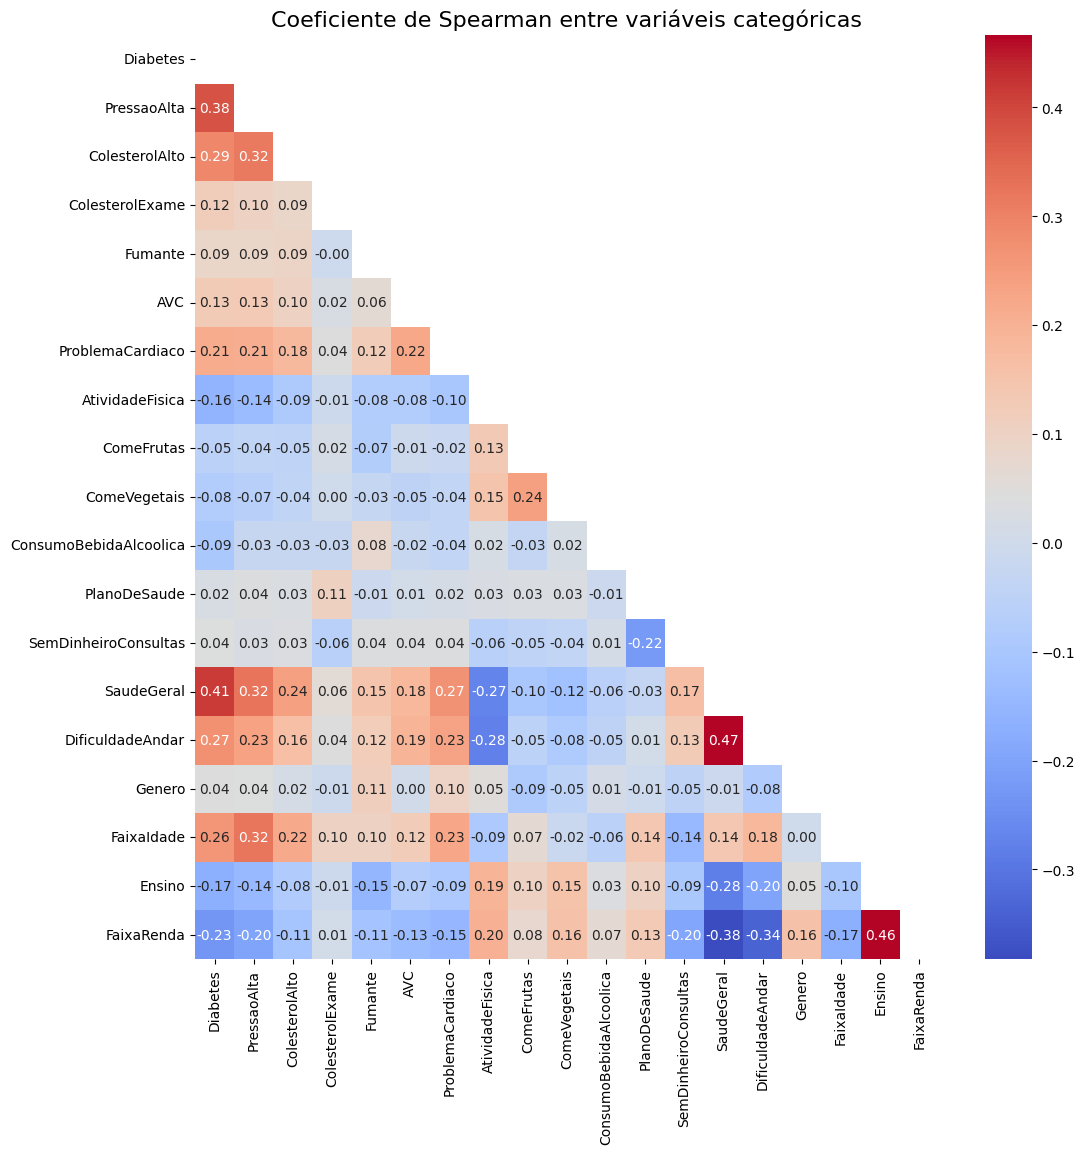

In [ ]:
import numpy as np

matriz = np.triu(resultados_correlacao)#Estou passando esse metodo do numpy pois o grafico estava muito reduntante porque o grafico do mapa de calor ele esta fazendo duas vezes a mesma coisa e esse metodo permite eu só pegar uma parte.Tanto que nome vem de triangulo ou seja eu vou pegar só uma parte

fig, ax = plt.subplots(figsize=(12, 12))#Deixamos um grafico um pouco grande para melhor vizualização

sns.heatmap(resultados_correlacao, mask=matriz, annot=True, fmt=".2f", ax=ax, cmap="coolwarm")#Heatmap é um grafico do seaborn de calor, apos usar a função do numpy para pegar essa parte e aplicar no parametro mask, annot eu coloco como True se eu quero ver os valores de correlação

plt.title("Coeficiente de Spearman entre variáveis categóricas", fontsize=16)

plt.show()

In [ ]:
#Correlações Positivas Fortes:

#SaudeGeral (0.41): Existe uma correlação positiva moderada a forte. Isso sugere que, à medida que a saúde geral da pessoa tende a ser pior (valores maiores, conforme seu dicionário de variáveis), a chance de ter diabetes aumenta. Isso é consistente com sua observação anterior de que quem tem diabetes tende a ter uma saúde geral mais baixa.
#DificuldadeAndar (0.27): Uma correlação positiva que indica que pessoas com dificuldade para andar têm maior probabilidade de ter diabetes.
#FaixaIdade (0.26): Uma correlação positiva que reforça a ideia de que a prevalência de diabetes aumenta com a idade.
#Correlações Negativas Fortes:

#Ensino (-0.17): Uma correlação negativa moderada. Isso sugere que quanto maior o nível de escolaridade, menor a probabilidade de ter diabetes. Isso se alinha com a observação que você fez sobre ensino e saúde geral.
#FaixaRenda (-0.23): Uma correlação negativa moderada. Pessoas com faixas de renda mais altas tendem a ter menor probabilidade de ter diabetes, o que também foi uma das suas conclusões ao analisar os histogramas.
#Outras Correlações: Variáveis como ColesterolAlto (0.29), ProblemaCardiaco (0.21) e AVC (0.13) também mostram correlações positivas com 'Diabetes', embora ligeiramente mais fracas que as citadas acima, mas ainda relevantes. Variáveis como AtividadeFisica (-0.16), ComeFrutas (-0.05) e ComeVegetais (-0.08) mostram correlações negativas, indicando que a prática de atividades físicas e o consumo de frutas/vegetais estão associados a uma menor chance de diabetes